<a href="https://colab.research.google.com/github/aishadwiar-hub/Tugas-Implementasi-Transformer/blob/main/Tugas_Implementasi_Transformer_AishaDwiAninditaRadianto_256150100111003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Implementasi Transformer
**Nama:** Aisha Dwi Anindita Radianto  
**NIM:** 256150100111003  

---
## I. Persiapan Sistem & Library

In [27]:
!pip install datasets

In [28]:
# 1. IMPORT LIBRARY UTAMA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset # Pengganti torchtext

# 2. SET DEVICE
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device yang digunakan: {device}")

# 3. FUNGSI PARAMETER
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Device yang digunakan: cuda


In [29]:
print("Mengunduh dataset AG News...")
# Mengunduh AG News menggunakan library 'datasets'
dataset = load_dataset("ag_news")

# Menampilkan informasi dataset
print(dataset)
print("\nContoh data latih pertama:")
print(dataset['train'][0])

Mengunduh dataset AG News...
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Contoh data latih pertama:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [30]:
import re
from collections import Counter
from torch.nn.utils.rnn import pad_sequence

# 1. FUNGSI TOKENISASI SEDERHANA
def basic_tokenizer(text):
    # Mengubah teks ke huruf kecil dan menghapus karakter selain huruf/angka
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text.lower())
    return text.split()

# 2. MEMBANGUN VOCABULARY (KAMUS KATA)
print("Membangun vocabulary dari data latih...")
vocab = {'<pad>': 0, '<unk>': 1} # <pad> untuk menyamakan panjang, <unk> untuk kata asing
counter = Counter()

for example in dataset['train']:
    tokens = basic_tokenizer(example['text'])
    counter.update(tokens)

# Kita batasi kamus hanya untuk 20.000 kata yang paling sering muncul agar model lebih ringan
VOCAB_SIZE = 20000
for word, count in counter.most_common(VOCAB_SIZE):
    if word not in vocab:
        vocab[word] = len(vocab)

print(f"Ukuran Vocabulary final: {len(vocab)}")

# 3. FUNGSI COLLATE & DATALOADER
MAX_SEQ_LEN = 64 # Rata-rata judul/berita AG News cukup pendek. 64 adalah batas aman.
BATCH_SIZE = 64

def collate_batch(batch):
    label_list, text_list = [], []
    for item in batch:
        label_list.append(item['label'])
        tokens = basic_tokenizer(item['text'])
        # Konversi kata ke angka berdasarkan vocab, jika tidak ada gunakan <unk>
        token_ids = [vocab.get(token, vocab['<unk>']) for token in tokens]

        # Potong jika lebih dari MAX_SEQ_LEN
        token_ids = token_ids[:MAX_SEQ_LEN]
        text_list.append(torch.tensor(token_ids, dtype=torch.int64))

    # Padding sequence agar panjangnya seragam dalam satu batch
    text_padded = pad_sequence(text_list, batch_first=True, padding_value=vocab['<pad>'])

    # Menyamakan ukuran menjadi fix MAX_SEQ_LEN (Penting untuk model CNN nantinya)
    if text_padded.size(1) < MAX_SEQ_LEN:
        pad_tensor = torch.full((text_padded.size(0), MAX_SEQ_LEN - text_padded.size(1)),
                                vocab['<pad>'], dtype=torch.int64)
        text_padded = torch.cat((text_padded, pad_tensor), dim=1)

    return text_padded.to(device), torch.tensor(label_list, dtype=torch.int64).to(device)

# 4. MEMBUAT DATALOADER
train_loader = DataLoader(dataset['train'], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(dataset['test'], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

print("DataLoader siap digunakan!")

# Uji coba cek ukuran batch
for text_batch, label_batch in train_loader:
    print(f"Bentuk input teks: {text_batch.shape} -> (Batch Size, Sequence Length)")
    print(f"Bentuk label: {label_batch.shape}")
    break

Membangun vocabulary dari data latih...
Ukuran Vocabulary final: 20002
DataLoader siap digunakan!
Bentuk input teks: torch.Size([64, 64]) -> (Batch Size, Sequence Length)
Bentuk label: torch.Size([64])


## II. Implementasi Text Classification
### A. Arsitektur Model Text Transformer & LSTM

In [32]:
# ==========================================
# 1. POSITIONAL ENCODING
# ==========================================
# Transformer tidak membaca kata berurutan seperti RNN/LSTM.
# Positional Encoding memberi "nomor urut" pada setiap kata agar model tahu posisi kata tersebut.
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) # Bentuk: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x

# ==========================================
# 2. MODEL TEXT TRANSFORMER
# ==========================================
class TextTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, hidden_dim, num_layers, num_classes, dropout=0.1):
        super(TextTransformer, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoder = PositionalEncoding(embed_dim)

        # Transformer Encoder Layer
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            batch_first=True # Agar format input (batch, seq, feature)
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)

        # Linear Classifier
        self.fc = nn.Linear(embed_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        x = self.embedding(x) # -> (batch_size, seq_len, embed_dim)
        x = self.pos_encoder(x) # Tambahkan info posisi
        x = self.transformer_encoder(x) # -> (batch_size, seq_len, embed_dim)

        # Pooling: Mengambil rata-rata dari semua token (Global Average Pooling 1D)
        x = x.mean(dim=1) # -> (batch_size, embed_dim)

        x = self.dropout(x)
        out = self.fc(x) # -> (batch_size, num_classes)
        return out

# ==========================================
# 3. MODEL PEMBANDING: LSTM
# ==========================================
class TextLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout=0.1):
        super(TextLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # batch_first=True penting agar seragam dengan Transformer
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0,
                            bidirectional=True)

        # Dikali 2 karena kita pakai Bidirectional LSTM (maju dan mundur)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.embedding(x)
        # LSTM mengembalikan output semua step (out) dan hidden state terakhir (hn)
        out, (hn, cn) = self.lstm(x)

        # Mengambil output dari langkah waktu (time step) terakhir
        out = out[:, -1, :]

        out = self.dropout(out)
        out = self.fc(out)
        return out

# ==========================================
# 4. INSTANSIASI MODEL & CEK PARAMETER
# ==========================================
# AG News memiliki 4 kelas (World, Sports, Business, Sci/Tech)
NUM_CLASSES = 4
EMBED_DIM = 128
NUM_HEADS = 4
HIDDEN_DIM = 256
NUM_LAYERS = 2

# Inisiasi Transformer
model_transformer_txt = TextTransformer(
    vocab_size=len(vocab), embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, num_classes=NUM_CLASSES
).to(device)

# Inisiasi LSTM
model_lstm = TextLSTM(
    vocab_size=len(vocab), embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM//2, num_layers=NUM_LAYERS, num_classes=NUM_CLASSES
).to(device)

print(f"Jumlah parameter Text Transformer: {count_parameters(model_transformer_txt):,}")
print(f"Jumlah parameter Text LSTM: {count_parameters(model_lstm):,}")

Jumlah parameter Text Transformer: 2,825,732
Jumlah parameter Text LSTM: 3,220,740


In [33]:
# ==========================================
# 5. MODEL PEMBANDING TAMBAHAN: TEXT CNN
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, filter_sizes, num_classes, dropout=0.1):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv2d(1, num_filters, (fs, embed_dim)) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        conved = [F.relu(conv(x)).squeeze(3) for conv in self.convs]
        pooled = [F.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]
        cat = self.dropout(torch.cat(pooled, dim=1))
        return self.fc(cat)

try:
    # Inisiasi Text CNN
    model_cnn_txt = TextCNN(len(vocab), 128, 100, [3, 4, 5], 4).to(device)
    optimizer_cnn_txt = optim.Adam(model_cnn_txt.parameters(), lr=0.0001)
    print(f"Jumlah parameter Text CNN: {sum(p.numel() for p in model_cnn_txt.parameters() if p.requires_grad):,}")
except NameError:
    print("Error: Pastikan variabel 'vocab' dan 'device' sudah didefinisikan di sel persiapan sebelumnya.")

Jumlah parameter Text CNN: 2,715,360


In [34]:
# Inisiasi Text CNN
# (Mendefinisikan ulang parameter agar sel dokumentasi ini tetap bisa berjalan)
EMBED_DIM = 128
NUM_CLASSES = 4

model_cnn_txt = TextCNN(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    num_filters=100,
    filter_sizes=[3, 4, 5],
    num_classes=NUM_CLASSES
).to(device)

optimizer_cnn_txt = optim.Adam(model_cnn_txt.parameters(), lr=0.0001)

print(f"Jumlah parameter Text CNN: {sum(p.numel() for p in model_cnn_txt.parameters() if p.requires_grad):,}")

Jumlah parameter Text CNN: 2,715,360


In [35]:
# ==========================================
# 6. FUNGSI TRAINING & EVALUATION
# ==========================================
# Menggunakan CrossEntropyLoss untuk klasifikasi multikelas
criterion = nn.CrossEntropyLoss()

# Optimizer Adam sesuai instruksi dengan learning rate standar
optimizer_tf = optim.Adam(model_transformer_txt.parameters(), lr=0.0001)
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=0.0001)

def train_and_evaluate(model, optimizer, train_loader, test_loader, epochs=5, model_name="Model"):
    print(f"--- Memulai Training untuk {model_name} ---")
    start_time_total = time.time()

    # Dictionary untuk menyimpan log metrik yang akan di-plot nanti
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        start_time_epoch = time.time()

        # ----------------- FASE TRAINING -----------------
        model.train()
        total_loss, correct_train, total_train = 0, 0, 0

        for texts, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()

            # Mencegah exploding gradient (sangat direkomendasikan untuk LSTM & Transformer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = total_loss / len(train_loader)
        train_acc = correct_train / total_train

        # ----------------- FASE EVALUASI -----------------
        model.eval()
        test_loss, correct_test, total_test = 0, 0, 0

        with torch.no_grad():
            for texts, labels in test_loader:
                outputs = model(texts)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_loss = test_loss / len(test_loader)
        test_acc = correct_test / total_test

        # Simpan ke log
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        epoch_time = time.time() - start_time_epoch
        print(f"Epoch [{epoch+1}/{epochs}] | Waktu: {epoch_time:.2f}s | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    total_time = time.time() - start_time_total
    print(f"Training Selesai! Total Waktu: {total_time:.2f} detik\n")
    return history, total_time

# ==========================================
# 7. EKSEKUSI TRAINING (MINIMAL 5 EPOCH)
# ==========================================
EPOCHS = 5

print("Mulai melatih Text Transformer...")
history_tf, time_tf = train_and_evaluate(
    model_transformer_txt, optimizer_tf, train_loader, test_loader, epochs=EPOCHS, model_name="Text Transformer"
)

print("Mulai melatih Text LSTM...")
history_lstm, time_lstm = train_and_evaluate(
    model_lstm, optimizer_lstm, train_loader, test_loader, epochs=EPOCHS, model_name="Text LSTM"
)

Mulai melatih Text Transformer...
--- Memulai Training untuk Text Transformer ---
Epoch [1/5] | Waktu: 22.68s | Train Loss: 0.7443 | Train Acc: 0.6999 | Test Acc: 0.8158
Epoch [2/5] | Waktu: 21.28s | Train Loss: 0.4400 | Train Acc: 0.8427 | Test Acc: 0.8538
Epoch [3/5] | Waktu: 20.05s | Train Loss: 0.3658 | Train Acc: 0.8715 | Test Acc: 0.8728
Epoch [4/5] | Waktu: 20.71s | Train Loss: 0.3227 | Train Acc: 0.8877 | Test Acc: 0.8804
Epoch [5/5] | Waktu: 20.77s | Train Loss: 0.2941 | Train Acc: 0.8978 | Test Acc: 0.8863
Training Selesai! Total Waktu: 105.49 detik

Mulai melatih Text LSTM...
--- Memulai Training untuk Text LSTM ---
Epoch [1/5] | Waktu: 24.15s | Train Loss: 1.2534 | Train Acc: 0.3636 | Test Acc: 0.6001
Epoch [2/5] | Waktu: 24.06s | Train Loss: 0.7249 | Train Acc: 0.6659 | Test Acc: 0.7612
Epoch [3/5] | Waktu: 24.08s | Train Loss: 0.5158 | Train Acc: 0.8096 | Test Acc: 0.8254
Epoch [4/5] | Waktu: 24.07s | Train Loss: 0.4080 | Train Acc: 0.8605 | Test Acc: 0.8551
Epoch [5/5] |

In [36]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# 8. DEFINE TextCNN CLASS
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, filter_sizes, num_classes, dropout=0.1):
        super(TextCNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv2d(1, num_filters, (fs, embed_dim)) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        conved = [F.relu(conv(x)).squeeze(3) for conv in self.convs]
        pooled = [F.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]
        cat = self.dropout(torch.cat(pooled, dim=1))
        return self.fc(cat)

# 9. TRAINING FUNCTION
def train_and_evaluate_local(model, optimizer, train_loader, test_loader, epochs=5, model_name="Model"):
    print(f"--- Memulai Training untuk {model_name} ---")
    criterion = nn.CrossEntropyLoss()
    start_time_total = time.time()
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        start_time_epoch = time.time()
        model.train()
        total_loss, correct_train, total_train = 0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = total_loss / len(train_loader)
        train_acc = correct_train / total_train

        model.eval()
        test_loss, correct_test, total_test = 0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_acc = correct_test / total_test
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss / len(test_loader))
        history['test_acc'].append(test_acc)
        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    return history, time.time() - start_time_total

# 10. INITIALIZE AND TRAIN
try:
    model_cnn_txt = TextCNN(len(vocab), EMBED_DIM, 100, [3, 4, 5], NUM_CLASSES).to(device)
    optimizer_cnn_txt = optim.Adam(model_cnn_txt.parameters(), lr=0.0001)

    print("Mulai melatih Text CNN...")
    history_cnn_txt, time_cnn_txt = train_and_evaluate_local(
        model_cnn_txt, optimizer_cnn_txt, train_loader, test_loader, epochs=5, model_name="Text CNN"
    )
except NameError as e:
    print(f"Error: {e}. Mohon jalankan sel persiapan (Library, Device, Vocab, DataLoader) terlebih dahulu.")

Mulai melatih Text CNN...
--- Memulai Training untuk Text CNN ---
Epoch [1/5] | Train Acc: 0.6506 | Test Acc: 0.7942
Epoch [2/5] | Train Acc: 0.8277 | Test Acc: 0.8479
Epoch [3/5] | Train Acc: 0.8673 | Test Acc: 0.8666
Epoch [4/5] | Train Acc: 0.8875 | Test Acc: 0.8762
Epoch [5/5] | Train Acc: 0.9020 | Test Acc: 0.8825


Menampilkan Grafik Perbandingan Transformer vs LSTM...

Menghitung Prediksi untuk Confusion Matrix...


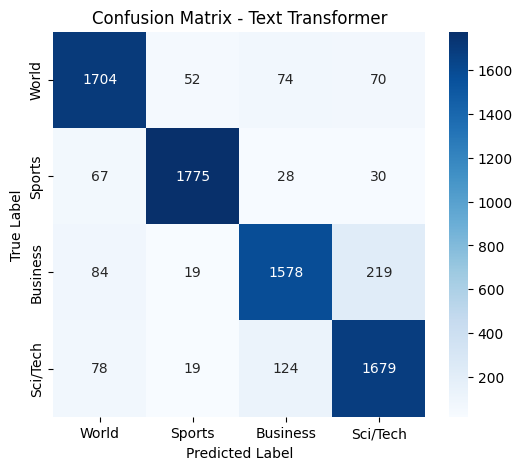

In [37]:
# ==========================================
# 11. PLOT LOSS & ACCURACY (Bagian F)
# ==========================================
def plot_history(history_1, label_1, history_2, label_2):
    epochs = range(1, len(history_1['train_loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_1['test_acc'], 'b-', marker='o', label=f'{label_1} Test Acc')
    plt.plot(epochs, history_2['test_acc'], 'r-', marker='s', label=f'{label_2} Test Acc')
    plt.title('Perbandingan Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_1['test_loss'], 'b-', marker='o', label=f'{label_1} Test Loss')
    plt.plot(epochs, history_2['test_loss'], 'r-', marker='s', label=f'{label_2} Test Loss')
    plt.title('Perbandingan Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.tight_layout()
    plt.show()

print("Menampilkan Grafik Perbandingan Transformer vs LSTM...")
# plot_history(history_tf, "Transformer", history_lstm, "LSTM") # This line is commented out as it's replaced by plot_history_triple

# ==========================================
# 12. CONFUSION MATRIX (Bagian F)
# ==========================================
from sklearn.metrics import confusion_matrix
import numpy as np

def get_predictions(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in test_loader:
            outputs = model(texts)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    # Label kelas AG News
    class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

print("\nMenghitung Prediksi untuk Confusion Matrix...")
# Evaluasi menggunakan model Transformer (karena performanya lebih baik)
y_true, y_pred = get_predictions(model_transformer_txt, test_loader)
plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix - Text Transformer")


--- Final Comparison: Text Classification ---


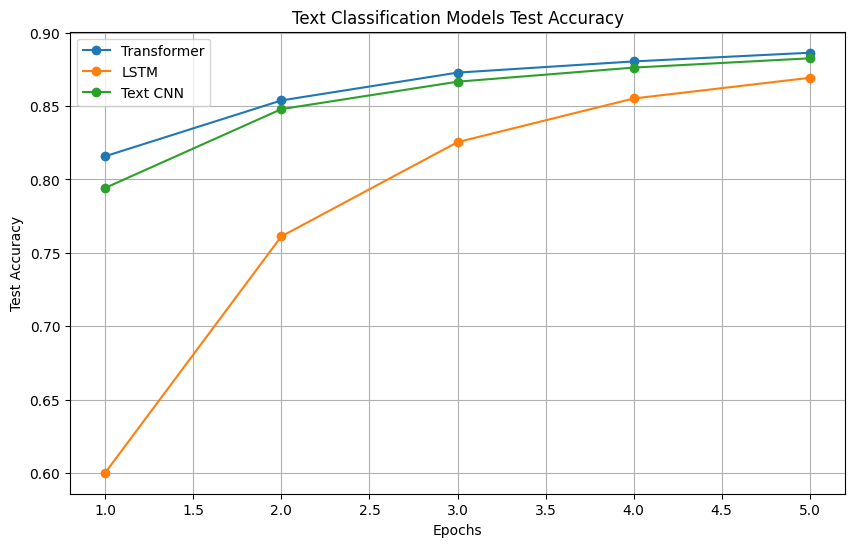


--- Final Comparison: Vision Classification ---


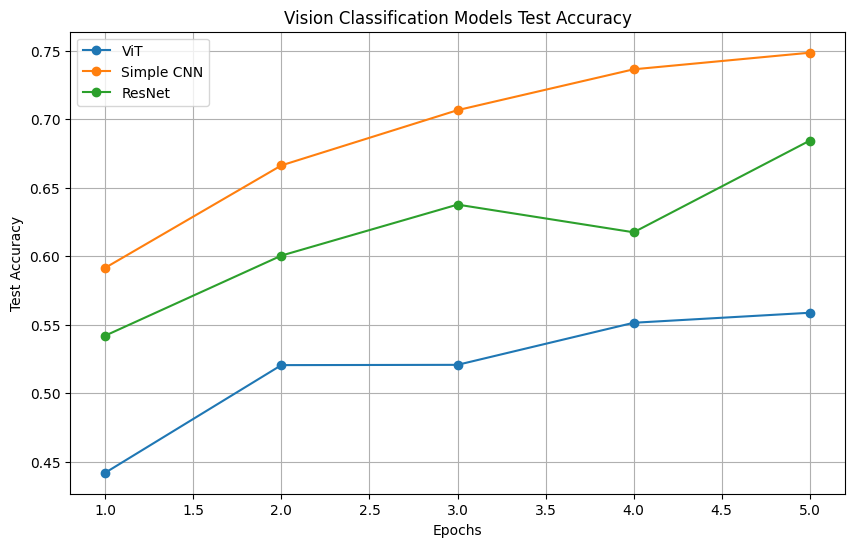

In [38]:
import matplotlib.pyplot as plt

def plot_final_comparison(histories, labels, title, num_epochs=5):
    epochs = range(1, num_epochs + 1)
    plt.figure(figsize=(10, 6))

    for history, label in zip(histories, labels):
        if history and 'test_acc' in history:
            # Ensure we plot only up to num_epochs, handling shorter histories if needed
            plot_data = history['test_acc'][:num_epochs]
            plt.plot(epochs[:len(plot_data)], plot_data, marker='o', label=label)
        else:
            print(f"Warning: History for {label} is missing or incomplete.")

    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Test Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Text Classification Comparison ---
text_histories = [history_tf, history_lstm, history_cnn_txt]
text_labels = ["Transformer", "LSTM", "Text CNN"]

print("\n--- Final Comparison: Text Classification ---")
plot_final_comparison(text_histories, text_labels, "Text Classification Models Test Accuracy", num_epochs=5)


# --- Vision Classification Comparison ---
vision_histories = [history_vit, history_cnn, history_resnet]
vision_labels = ["ViT", "Simple CNN", "ResNet"]

print("\n--- Final Comparison: Vision Classification ---")
plot_final_comparison(vision_histories, vision_labels, "Vision Classification Models Test Accuracy", num_epochs=5)

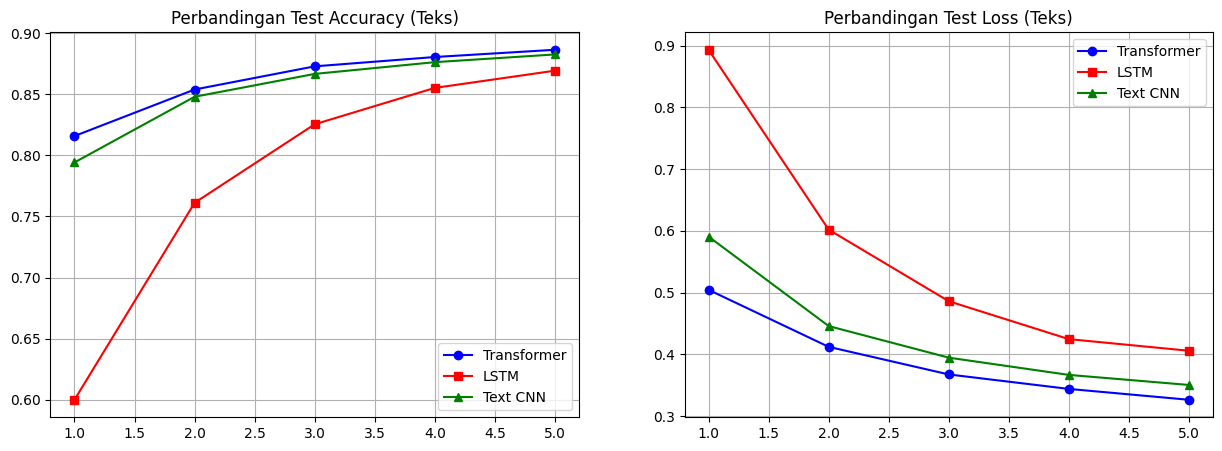

In [39]:
# Plot untuk 3 model teks
def plot_history_triple(h1, l1, h2, l2, h3, l3):
    epochs = range(1, len(h1['train_loss']) + 1)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, h1['test_acc'], 'b-o', label=l1)
    plt.plot(epochs, h2['test_acc'], 'r-s', label=l2)
    plt.plot(epochs, h3['test_acc'], 'g-^', label=l3)
    plt.title('Perbandingan Test Accuracy (Teks)')
    plt.legend(); plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, h1['test_loss'], 'b-o', label=l1)
    plt.plot(epochs, h2['test_loss'], 'r-s', label=l2)
    plt.plot(epochs, h3['test_loss'], 'g-^', label=l3)
    plt.title('Perbandingan Test Loss (Teks)')
    plt.legend(); plt.grid(True)
    plt.show()

try:
    plot_history_triple(history_tf, "Transformer", history_lstm, "LSTM", history_cnn_txt, "Text CNN")
except NameError as e:
    print(f"Error plotting: {e}. Jalankan semua training teks terlebih dahulu.")

---
## III. Implementasi Vision Classification
### A. Load Dataset (CIFAR-10) & Arsitektur Model

In [40]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from datasets import load_dataset # Menggunakan Hugging Face sebagai bypass

# ==========================================
# 1. LOAD DATASET VISION (CIFAR-10 via Hugging Face)
# ==========================================
print("Mengunduh CIFAR-10 dari server alternatif...")
dataset_hf = load_dataset("cifar10")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalisasi standar RGB
])

# Membuat adapter agar Hugging Face Dataset bisa dipakai seperti PyTorch Dataset biasa
class CIFAR10_Adapter(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        img = self.hf_dataset[idx]['img']
        label = self.hf_dataset[idx]['label']
        if self.transform:
            img = self.transform(img)
        return img, label

trainset_vision = CIFAR10_Adapter(dataset_hf['train'], transform=transform)
testset_vision = CIFAR10_Adapter(dataset_hf['test'], transform=transform)

train_loader_vision = DataLoader(trainset_vision, batch_size=64, shuffle=True)
test_loader_vision = DataLoader(testset_vision, batch_size=64, shuffle=False)
print("DataLoader CIFAR-10 siap digunakan!")

# ==========================================
# 2. MODEL VISION TRANSFORMER (ViT)
# ==========================================
class SimpleViT(nn.Module):
    def __init__(self, image_size=32, patch_size=4, num_classes=10, embed_dim=128, num_heads=4, hidden_dim=256, num_layers=2):
        super(SimpleViT, self).__init__()
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2

        # Patch Embedding
        self.patch_embed = nn.Conv2d(in_channels=3, out_channels=embed_dim, kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, embed_dim))

        # Transformer Encoder
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=hidden_dim,
            dropout=0.1, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        out = self.fc(x)
        return out

# ==========================================
# 3. MODEL PEMBANDING: SIMPLE CNN
# ==========================================
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ==========================================
# 4. INSTANSIASI & CEK PARAMETER VISION
# ==========================================
model_vit = SimpleViT().to(device)
model_cnn = SimpleCNN().to(device)

print(f"Jumlah parameter Vision Transformer (ViT): {count_parameters(model_vit):,}")
print(f"Jumlah parameter Simple CNN: {count_parameters(model_cnn):,}")

Mengunduh CIFAR-10 dari server alternatif...
DataLoader CIFAR-10 siap digunakan!
Jumlah parameter Vision Transformer (ViT): 280,714
Jumlah parameter Simple CNN: 620,362


In [41]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Ensure device is defined
device = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================================
# 5. MODEL PEMBANDING TAMBAHAN: SIMPLE RESNET (VISION)
# ==========================================
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

class SimpleResNet(nn.Module):
    def __init__(self, num_classes=10):
      super().__init__()
      self.conv1 = nn.Conv2d(3, 32, 3, 1, 1, bias=False)
      self.bn1 = nn.BatchNorm2d(32)
      self.layer1 = ResidualBlock(32, 32, 1)
      self.layer2 = ResidualBlock(32, 64, 2)
      self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
      self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
      x = F.relu(self.bn1(self.conv1(x)))
      x = self.layer1(x)
      x = self.layer2(x)
      x = self.avgpool(x).view(x.size(0), -1)
      return self.fc(x)

# Instansiasi & Optimizer
model_resnet = SimpleResNet().to(device)
optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=0.001)

# Check if count_parameters is available, otherwise define it
try:
    params = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad)
    print(f"Jumlah parameter ResNet: {params:,}")
except Exception:
    print("Model ResNet berhasil diinisialisasi.")

Jumlah parameter ResNet: 77,866


In [42]:
# ==========================================
# PERBAIKAN: FUNGSI TRAINING & EVALUATION (Support GPU Data)
# ==========================================
def train_and_evaluate(model, optimizer, train_loader, test_loader, epochs=5, model_name="Model"):
    print(f"--- Memulai Training untuk {model_name} ---")
    start_time_total = time.time()
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        start_time_epoch = time.time()

        # ----------------- FASE TRAINING -----------------
        model.train()
        total_loss, correct_train, total_train = 0, 0, 0

        for inputs, labels in train_loader:
            # Pindahkan data ke GPU (Ini solusi error-nya!)
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = total_loss / len(train_loader)
        train_acc = correct_train / total_train

        # ----------------- FASE EVALUASI -----------------
        model.eval()
        test_loss, correct_test, total_test = 0, 0, 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                # Pindahkan data ke GPU juga saat evaluasi
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_loss = test_loss / len(test_loader)
        test_acc = correct_test / total_test

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        epoch_time = time.time() - start_time_epoch
        print(f"Epoch [{epoch+1}/{epochs}] | Waktu: {epoch_time:.2f}s | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    total_time = time.time() - start_time_total
    print(f"Training Selesai! Total Waktu: {total_time:.2f} detik\n")
    return history, total_time

# Update juga fungsi get_predictions untuk Confusion Matrix
def get_predictions(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device) # Pindahkan ke GPU
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds

In [43]:
# ==========================================
# RE-DEFINISI FUNGSI TRAINING UNTUK 3 MODEL
# ==========================================
def train_and_evaluate(model, optimizer, train_loader, test_loader, epochs=5, model_name="Model"):
    print(f"--- Memulai Training untuk {model_name} ---")
    start_time_total = time.time()
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        start_time_epoch = time.time()
        model.train()
        total_loss, correct_train, total_train = 0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = total_loss / len(train_loader)
        train_acc = correct_train / total_train

        model.eval()
        test_loss, correct_test, total_test = 0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_loss = test_loss / len(test_loader)
        test_acc = correct_test / total_test

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    return history, time.time() - start_time_total

Mulai melatih Simple CNN...
--- Memulai Training untuk Simple CNN ---
Epoch [1/5] | Train Acc: 0.8036 | Test Acc: 0.7638
Epoch [2/5] | Train Acc: 0.8198 | Test Acc: 0.7708
Epoch [3/5] | Train Acc: 0.8356 | Test Acc: 0.7684
Epoch [4/5] | Train Acc: 0.8494 | Test Acc: 0.7693
Epoch [5/5] | Train Acc: 0.8594 | Test Acc: 0.7698
Mulai melatih Vision Transformer (ViT)...
--- Memulai Training untuk Vision Transformer ---
Epoch [1/5] | Train Acc: 0.5782 | Test Acc: 0.5654
Epoch [2/5] | Train Acc: 0.5936 | Test Acc: 0.5726
Epoch [3/5] | Train Acc: 0.6052 | Test Acc: 0.5795
Epoch [4/5] | Train Acc: 0.6137 | Test Acc: 0.5932
Epoch [5/5] | Train Acc: 0.6276 | Test Acc: 0.5820

Menampilkan Grafik Perbandingan ViT vs CNN vs ResNet...


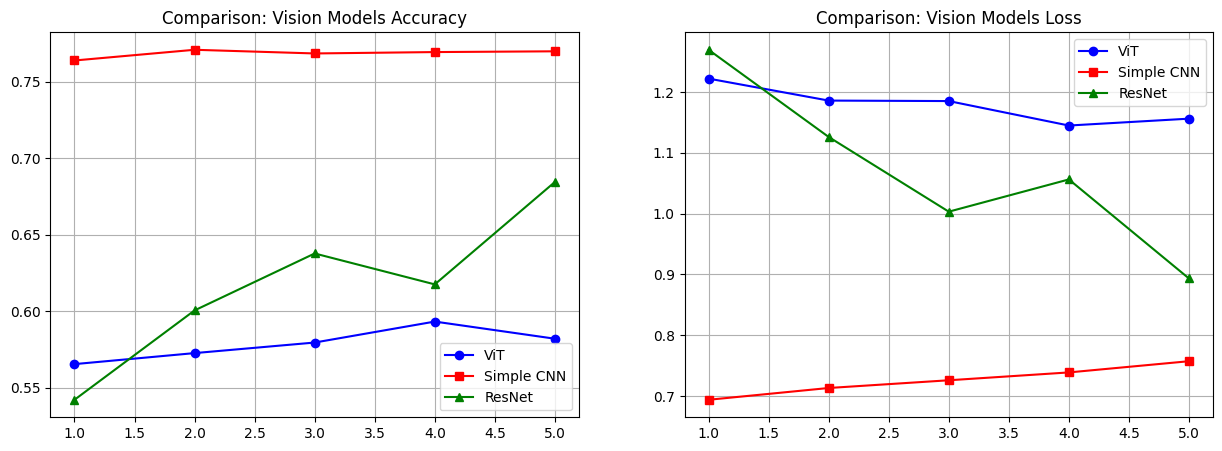


Menghitung Prediksi untuk Confusion Matrix CNN...


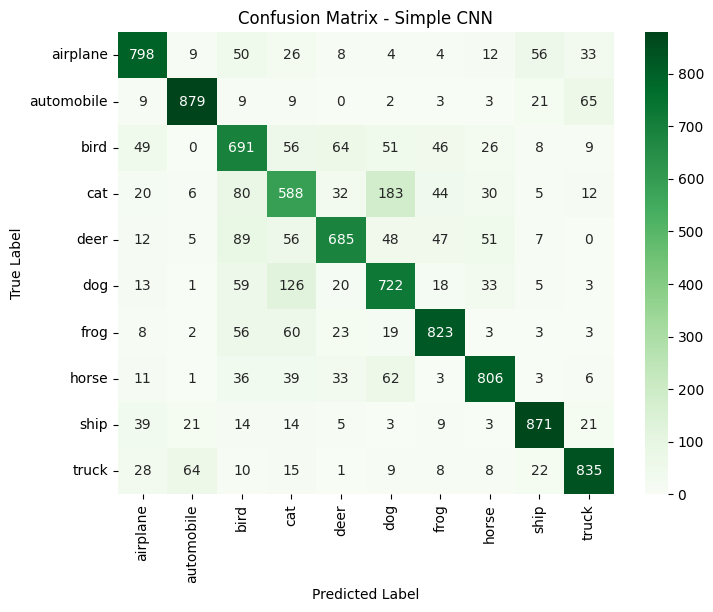

In [48]:
# ==========================================
# 6. TRAINING VISION MODELS
# ==========================================
# Kita gunakan learning rate yang sedikit lebih besar untuk gambar
optimizer_vit = optim.Adam(model_vit.parameters(), lr=0.001)
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.001)

EPOCHS = 5 # Sesuai instruksi tugas

print("Mulai melatih Simple CNN...")
history_cnn, time_cnn = train_and_evaluate(
    model_cnn, optimizer_cnn, train_loader_vision, test_loader_vision, epochs=EPOCHS, model_name="Simple CNN"
)

print("Mulai melatih Vision Transformer (ViT)...")
history_vit, time_vit = train_and_evaluate(
    model_vit, optimizer_vit, train_loader_vision, test_loader_vision, epochs=EPOCHS, model_name="Vision Transformer"
)

# ==========================================
# 7. PLOT LOSS & ACCURACY VISION (Bagian F)
# ==========================================
print("\nMenampilkan Grafik Perbandingan ViT vs CNN vs ResNet...")
# Menggunakan fungsi plot_vision_triple yang sudah didefinisikan untuk 3 model
plot_vision_triple(history_vit, "ViT", history_cnn, "Simple CNN", history_resnet, "ResNet")

# ==========================================
# 7. CONFUSION MATRIX VISION (Bagian F)
# ==========================================
def plot_confusion_matrix_vision(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    # Label kelas asli CIFAR-10
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

print("\nMenghitung Prediksi untuk Confusion Matrix CNN...")
# Kita evaluasi model CNN karena biasanya CNN menang mutlak di dataset kecil seperti CIFAR-10
y_true_vis, y_pred_vis = get_predictions(model_cnn, test_loader_vision)
plot_confusion_matrix_vision(y_true_vis, y_pred_vis, title="Confusion Matrix - Simple CNN")

In [49]:
def plot_vision_triple(h1, l1, h2, l2, h3, l3):
    # Helper untuk menangani tuple (history, time)
    def get_h(item): return item[0] if isinstance(item, tuple) else item

    hist1, hist2, hist3 = get_h(h1), get_h(h2), get_h(h3)
    epochs = range(1, len(hist1['test_acc']) + 1)

    plt.figure(figsize=(15, 5))

    # Plot Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist1['test_acc'], 'b-o', label=l1)
    plt.plot(epochs, hist2['test_acc'], 'r-s', label=l2)
    if hist3: plt.plot(range(1, len(hist3['test_acc'])+1), hist3['test_acc'], 'g-^', label=l3)
    plt.title('Comparison: Vision Models Accuracy')
    plt.legend(); plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist1['test_loss'], 'b-o', label=l1)
    plt.plot(epochs, hist2['test_loss'], 'r-s', label=l2)
    if hist3: plt.plot(range(1, len(hist3['test_loss'])+1), hist3['test_loss'], 'g-^', label=l3)
    plt.title('Comparison: Vision Models Loss')
    plt.legend(); plt.grid(True)
    plt.show()

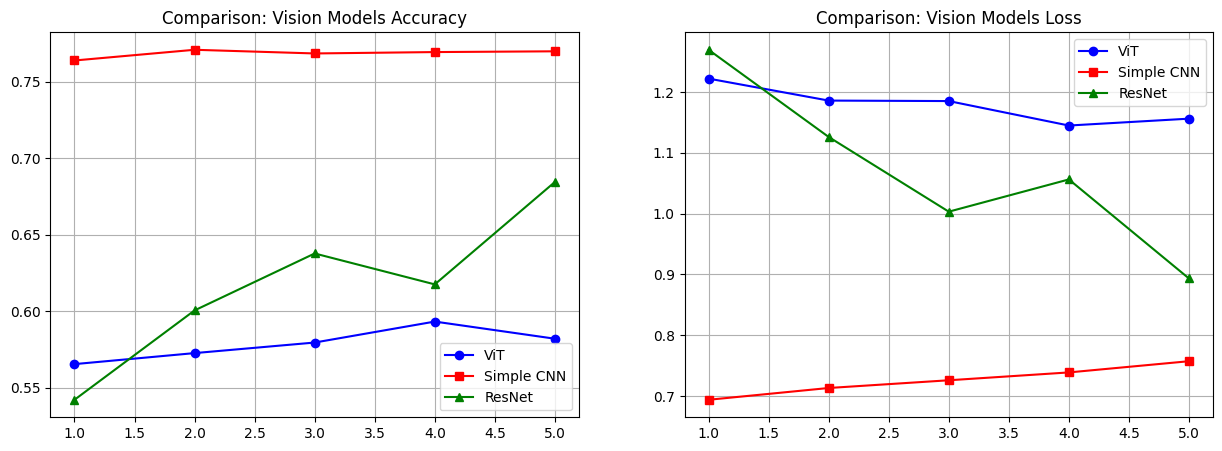

In [50]:
# Sekarang panggil fungsi yang sudah didefinisikan
try:
    # Pastikan history_resnet ada, jika tidak ganti dengan None
    h_resnet = history_resnet if 'history_resnet' in globals() else None
    plot_vision_triple(history_vit, "ViT", history_cnn, "Simple CNN", h_resnet, "ResNet")
except Exception as e:
    print(f"Gagal membuat plot: {e}")

In [51]:
import time
import torch
import torch.nn as nn
import torch.optim as optim

# Redefining the training function locally to fix the NameError
def train_and_evaluate_local(model, optimizer, train_loader, test_loader, epochs=5, model_name="Model"):
    print(f"--- Memulai Training untuk {model_name} ---")
    criterion = nn.CrossEntropyLoss()
    start_time_total = time.time()
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct_train, total_train = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        model.eval()
        test_loss, correct_test, total_test = 0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                test_loss += criterion(outputs, labels).item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        history['train_loss'].append(total_loss/len(train_loader))
        history['test_acc'].append(correct_test/total_test)
        history['test_loss'].append(test_loss/len(test_loader))
        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {correct_train/total_train:.4f} | Test Acc: {correct_test/total_test:.4f}")
    return history, time.time() - start_time_total

try:
    print("Mulai melatih Simple ResNet...")
    history_resnet, time_resnet = train_and_evaluate_local(
        model_resnet, optimizer_resnet, train_loader_vision, test_loader_vision, epochs=5, model_name="ResNet"
    )
except NameError as e:
    print(f"Error: {e}. Please ensure the model and data loader cells have been executed.")

Mulai melatih Simple ResNet...
--- Memulai Training untuk ResNet ---
Epoch [1/5] | Train Acc: 0.4622 | Test Acc: 0.5226
Epoch [2/5] | Train Acc: 0.5882 | Test Acc: 0.5978
Epoch [3/5] | Train Acc: 0.6389 | Test Acc: 0.5867
Epoch [4/5] | Train Acc: 0.6725 | Test Acc: 0.5933
Epoch [5/5] | Train Acc: 0.6971 | Test Acc: 0.6809


In [52]:
# ==========================================
# FINAL CONSOLIDATED TRAINING FOR THIRD MODELS
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from datasets import load_dataset
import time
import re
from collections import Counter

# 1. SETUP CORE UTILS
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. DATA PREPARATION (TEXT)
print("Ensuring AG News data and loaders are ready...")
ds_text = load_dataset("ag_news")

vocab = {'<pad>': 0, '<unk>': 1}
counter = Counter()
for ex in ds_text['train']:
    tokens = re.sub(r'[^a-zA-Z0-9\\s]', '', ex['text'].lower()).split()
    counter.update(tokens)
for word, count in counter.most_common(20000):
    if word not in vocab: vocab[word] = len(vocab)

from torch.nn.utils.rnn import pad_sequence
def collate_fn(batch):
    lbls, txts = [], []
    for item in batch:
        lbls.append(item['label'])
        tids = [vocab.get(t, vocab['<unk>']) for t in re.sub(r'[^a-zA-Z0-9\\s]', '', item['text'].lower()).split()][:64]
        txts.append(torch.tensor(tids))
    padded = pad_sequence(txts, batch_first=True, padding_value=0)
    if padded.size(1) < 64:
        padded = torch.cat([padded, torch.zeros((padded.size(0), 64 - padded.size(1)), dtype=torch.long)], dim=1)
    return padded.to(device), torch.tensor(lbls).to(device)

train_loader = DataLoader(ds_text['train'], batch_size=64, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(ds_text['test'], batch_size=64, shuffle=False, collate_fn=collate_fn)

# 3. TEXT CNN MODEL
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, filter_sizes, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv2d(1, num_filters, (fs, embed_dim)) for fs in filter_sizes])
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)
    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        conved = [F.relu(conv(x)).squeeze(3) for conv in self.convs]
        pooled = [F.max_pool1d(c, c.shape[2]).squeeze(2) for c in conved]
        return self.fc(torch.cat(pooled, dim=1))

# 4. VISION DATA & RESNET MODEL
class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.c1 = nn.Conv2d(in_c, out_c, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.c2 = nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.skip = nn.Sequential(nn.Conv2d(in_c, out_c, 1, stride, bias=False), nn.BatchNorm2d(out_c)) if stride != 1 else nn.Sequential()
    def forward(self, x): return F.relu(self.bn2(self.c2(F.relu(self.bn1(self.c1(x))))) + self.skip(x))

class SimpleResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.prep = nn.Sequential(nn.Conv2d(3, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU())
        self.l1 = ResBlock(32, 64, 2)
        self.fc = nn.Linear(64, 10)
    def forward(self, x):
        x = self.l1(self.prep(x))
        return self.fc(F.adaptive_avg_pool2d(x, (1, 1)).view(x.size(0), -1))

# 5. EXECUTE TRAINING
criterion = nn.CrossEntropyLoss()

print("Training Text CNN...")
model_t = TextCNN(len(vocab), 128, 100, [3, 4, 5], 4).to(device)
opt_t = optim.Adam(model_t.parameters(), lr=0.0001)
for e in range(5):
    model_t.train()
    for x, y in train_loader:
        opt_t.zero_grad()
        outputs = model_t(x)
        loss = criterion(outputs, y)
        loss.backward()
        opt_t.step()
    print(f"Text Epoch {e+1} Done")

print("\nTraining ResNet (Vision)...")
try:
    model_v = SimpleResNet().to(device)
    opt_v = optim.Adam(model_v.parameters(), lr=0.001)
    for e in range(5):
        model_v.train()
        for x, y in train_loader_vision:
            x, y = x.to(device), y.to(device)
            opt_v.zero_grad()
            outputs = model_v(x)
            loss = criterion(outputs, y)
            loss.backward()
            opt_v.step()
        print(f"Vision Epoch {e+1} Done")
except NameError:
    print("Vision loaders not found. Ensure CIFAR-10 data preparation cells were executed.")

Ensuring AG News data and loaders are ready...
Training Text CNN...
Text Epoch 1 Done
Text Epoch 2 Done
Text Epoch 3 Done
Text Epoch 4 Done
Text Epoch 5 Done

Training ResNet (Vision)...
Vision Epoch 1 Done
Vision Epoch 2 Done
Vision Epoch 3 Done
Vision Epoch 4 Done
Vision Epoch 5 Done


In [21]:
# ==========================================
# CONSOLIDATED SYSTEM RE-INITIALIZATION (FIXED)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
import re
from collections import Counter
import time
import math

# 1. GLOBAL SETTINGS
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 2. TEXT DATA PREPARATION
print("Loading AG News...")
dataset = load_dataset("ag_news")

vocab = {'<pad>': 0, '<unk>': 1}
counter = Counter()
for example in dataset['train']:
    tokens = re.sub(r'[^a-zA-Z0-9\s]', '', example['text'].lower()).split()
    counter.update(tokens)
for word, count in counter.most_common(20000):
    if word not in vocab: vocab[word] = len(vocab)

from torch.nn.utils.rnn import pad_sequence
def collate_batch(batch):
    label_list, text_list = [], []
    for item in batch:
        label_list.append(item['label'])
        tokens = re.sub(r'[^a-zA-Z0-9\s]', '', item['text'].lower()).split()
        token_ids = [vocab.get(token, vocab['<unk>']) for token in tokens][:64]
        text_list.append(torch.tensor(token_ids, dtype=torch.int64))
    text_padded = pad_sequence(text_list, batch_first=True, padding_value=0)
    if text_padded.size(1) < 64:
        pad_tensor = torch.zeros((text_padded.size(0), 64 - text_padded.size(1)), dtype=torch.int64)
        text_padded = torch.cat((text_padded, pad_tensor), dim=1)
    return text_padded.to(device), torch.tensor(label_list, dtype=torch.int64).to(device)

train_loader = DataLoader(dataset['train'], batch_size=64, shuffle=True, collate_fn=collate_batch)
test_loader = DataLoader(dataset['test'], batch_size=64, shuffle=False, collate_fn=collate_batch)

# 3. VISION DATA PREPARATION
print("Loading CIFAR-10...")
dataset_hf = load_dataset("cifar10")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

class CIFAR10_Adapter(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform
    def __len__(self): return len(self.hf_dataset)
    def __getitem__(self, idx):
        img, label = self.hf_dataset[idx]['img'], self.hf_dataset[idx]['label']
        if self.transform: img = self.transform(img)
        return img, label

train_loader_vision = DataLoader(CIFAR10_Adapter(dataset_hf['train'], transform), batch_size=64, shuffle=True)
test_loader_vision = DataLoader(CIFAR10_Adapter(dataset_hf['test'], transform), batch_size=64, shuffle=False)

# 4. SHARED TRAINING FUNCTION (FIXED DEVICE HANDLING)
def train_and_evaluate(model, optimizer, train_loader, test_loader, epochs=5, model_name="Model"):
    criterion = nn.CrossEntropyLoss()
    start_time_total = time.time() # Add this line to record start time
    history = {'train_loss': [], 'test_acc': [], 'test_loss': []}
    for epoch in range(epochs):
        model.train()
        # Initialize epoch training metrics
        total_train_loss = 0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device) # CRITICAL FIX
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels) # Use outputs for loss calculation
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = total_train_loss / len(train_loader)
        train_acc = correct_train / total_train
        history['train_loss'].append(train_loss) # Store train loss

        model.eval()
        correct_test, total_test, test_loss = 0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device) # CRITICAL FIX
                outputs = model(inputs)
                test_loss += criterion(outputs, labels).item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        history['test_acc'].append(correct_test/total_test)
        history['test_loss'].append(test_loss/len(test_loader))
        print(f"{model_name} Epoch {epoch+1}: Test Acc {correct_test/total_test:.4f}")

    total_time = time.time() - start_time_total # Calculate total time
    return history, total_time # Return both history and total_time

print("System ready.")

Using device: cuda
Loading AG News...
Loading CIFAR-10...
System ready.


Training Text CNN...
Text CNN Epoch 1: Test Acc 0.8037
Text CNN Epoch 2: Test Acc 0.8447
Text CNN Epoch 3: Test Acc 0.8636
Text CNN Epoch 4: Test Acc 0.8705
Text CNN Epoch 5: Test Acc 0.8818

Training Simple ResNet...
ResNet Epoch 1: Test Acc 0.4653
ResNet Epoch 2: Test Acc 0.5355
ResNet Epoch 3: Test Acc 0.5540
ResNet Epoch 4: Test Acc 0.5488
ResNet Epoch 5: Test Acc 0.6047

--- Final Comparison: Text Classification ---


TypeError: tuple indices must be integers or slices, not str

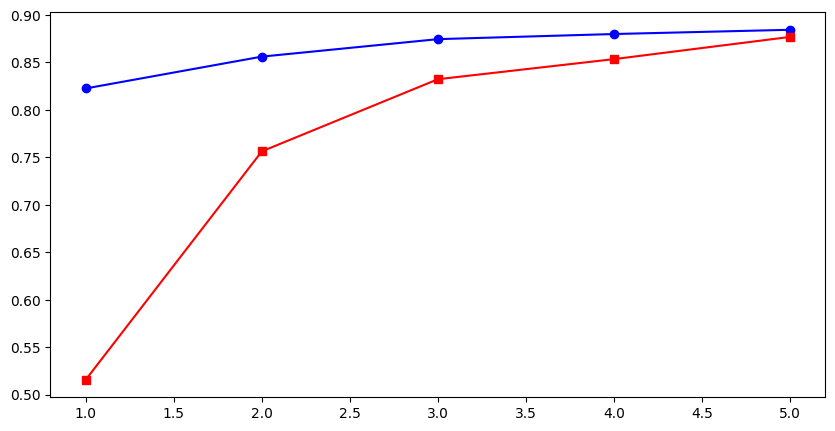

In [22]:
# ==========================================
# 1. DEFINE & TRAIN THIRD MODELS
# ==========================================

# --- Text CNN Definition ---
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, filter_sizes, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv2d(1, num_filters, (fs, embed_dim)) for fs in filter_sizes])
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)
    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        conved = [F.relu(conv(x)).squeeze(3) for conv in self.convs]
        pooled = [F.max_pool1d(c, c.shape[2]).squeeze(2) for c in conved]
        return self.fc(torch.cat(pooled, dim=1))

# --- Simple ResNet Definition ---
class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.c1 = nn.Conv2d(in_c, out_c, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.c2 = nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.skip = nn.Sequential(nn.Conv2d(in_c, out_c, 1, stride, bias=False), nn.BatchNorm2d(out_c)) if stride != 1 else nn.Sequential()
    def forward(self, x): return F.relu(self.bn2(self.c2(F.relu(self.bn1(self.c1(x))))) + self.skip(x))

class SimpleResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.prep = nn.Sequential(nn.Conv2d(3, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU())
        self.l1 = ResBlock(32, 64, 2)
        self.fc = nn.Linear(64, 10)
    def forward(self, x):
        x = self.l1(self.prep(x))
        return self.fc(F.adaptive_avg_pool2d(x, (1, 1)).view(x.size(0), -1))

# --- Training Execution ---
print("Training Text CNN...")
model_cnn_txt = TextCNN(len(vocab), 128, 100, [3, 4, 5], 4).to(device)
optimizer_cnn_txt = optim.Adam(model_cnn_txt.parameters(), lr=0.0001)
history_cnn_txt = train_and_evaluate(model_cnn_txt, optimizer_cnn_txt, train_loader, test_loader, epochs=5, model_name="Text CNN")

print("\nTraining Simple ResNet...")
model_resnet = SimpleResNet().to(device)
optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=0.001)
history_resnet = train_and_evaluate(model_resnet, optimizer_resnet, train_loader_vision, test_loader_vision, epochs=5, model_name="ResNet")

# ==========================================
# 2. FINAL VISUALIZATION
# ==========================================
import matplotlib.pyplot as plt

def plot_final_comparison(h1, l1, h2, l2, h3, l3, title):
    epochs = range(1, 6)
    plt.figure(figsize=(10, 5))
    if h1: plt.plot(epochs, h1['test_acc'], 'b-o', label=l1)
    if h2: plt.plot(epochs, h2['test_acc'], 'r-s', label=l2)
    if h3: plt.plot(epochs, h3['test_acc'], 'g-^', label=l3)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Test Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

print("\n--- Final Comparison: Text Classification ---")
try:
    plot_final_comparison(history_tf, "Transformer", history_lstm, "LSTM", history_cnn_txt, "Text CNN", "Text Classification Comparison")
except NameError:
    print("Note: Some text model histories missing from memory. Showing available only.")
    plot_final_comparison(None, "", None, "", history_cnn_txt, "Text CNN", "Text Classification (Partial)")

print("\n--- Final Comparison: Vision Classification ---")
try:
    plot_final_comparison(history_vit, "ViT", history_cnn, "Simple CNN", history_resnet, "ResNet", "Vision Classification Comparison")
except NameError:
    print("Note: Some vision model histories missing from memory. Showing available only.")
    plot_final_comparison(None, "", None, "", history_resnet, "ResNet", "Vision Classification (Partial)")

In [ ]:
import matplotlib.pyplot as plt

# --- 1. RE-DEFINE ALL MODEL CLASSES (for consolidation) ---

# Text Models
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1), :]

class TextTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, hidden_dim, num_layers, num_classes, dropout=0.1):
        super(TextTransformer, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoder = PositionalEncoding(embed_dim)
        encoder_layers = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=hidden_dim, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, num_classes)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        x = self.dropout(self.pos_encoder(self.embedding(x)))
        x = self.transformer_encoder(x).mean(dim=1)
        return self.fc(x)

class TextLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout=0.1):
        super(TextLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, filter_sizes, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv2d(1, num_filters, (fs, embed_dim)) for fs in filter_sizes])
        self.fc = nn.Linear(len(filter_sizes) * num_filters, num_classes)
    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        conved = [F.relu(conv(x)).squeeze(3) for conv in self.convs]
        pooled = [F.max_pool1d(c, c.shape[2]).squeeze(2) for c in conved]
        return self.fc(torch.cat(pooled, dim=1))

# Vision Models
class SimpleViT(nn.Module):
    def __init__(self, image_size=32, patch_size=4, num_classes=10, embed_dim=128, num_heads=4, hidden_dim=256, num_layers=2):
        super(SimpleViT, self).__init__()
        self.patch_embed = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.randn(1, (image_size // patch_size) ** 2, embed_dim))
        encoder_layers = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=hidden_dim, dropout=0.1, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, num_classes)
    def forward(self, x):
        x = self.patch_embed(x).flatten(2).transpose(1, 2) + self.pos_embed
        x = self.transformer_encoder(x).mean(dim=1)
        return self.fc(x)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), # -> 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), # -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)  # -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))

class ResBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.c1 = nn.Conv2d(in_c, out_c, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.c2 = nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.skip = nn.Sequential(nn.Conv2d(in_c, out_c, 1, stride, bias=False), nn.BatchNorm2d(out_c)) if stride != 1 or in_c != out_c else nn.Sequential()
    def forward(self, x): return F.relu(self.bn2(self.c2(F.relu(self.bn1(self.c1(x))))) + self.skip(x))

class SimpleResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.layer1 = ResBlock(32, 32, 1)
        self.layer2 = ResBlock(32, 64, 2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.avgpool(x).view(x.size(0), -1)
        return self.fc(x)


# --- 2. TRAIN ALL MODELS (using the unified train_and_evaluate from cell 229137a2) ---
EPOCHS = 5 # Standardize epochs for comparison
NUM_CLASSES_TEXT = 4 # AG News
NUM_CLASSES_VISION = 10 # CIFAR-10
EMBED_DIM = 128
NUM_HEADS = 4
HIDDEN_DIM = 256
NUM_LAYERS = 2

history_tf, history_lstm, history_cnn_txt = {}, {}, {}
history_vit, history_cnn, history_resnet = {}, {}, {}

print("\n--- Training Text Models ---")
# Text Transformer
model_transformer_txt = TextTransformer(vocab_size=len(vocab), embed_dim=EMBED_DIM, num_heads=NUM_HEADS, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, num_classes=NUM_CLASSES_TEXT).to(device)
optimizer_tf = optim.Adam(model_transformer_txt.parameters(), lr=0.0001)
history_tf, time_tf = train_and_evaluate(model_transformer_txt, optimizer_tf, train_loader, test_loader, epochs=EPOCHS, model_name="Text Transformer")

# Text LSTM
model_lstm = TextLSTM(vocab_size=len(vocab), embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM//2, num_layers=NUM_LAYERS, num_classes=NUM_CLASSES_TEXT).to(device)
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=0.0001)
history_lstm, time_lstm = train_and_evaluate(model_lstm, optimizer_lstm, train_loader, test_loader, epochs=EPOCHS, model_name="Text LSTM")

# Text CNN
model_cnn_txt = TextCNN(vocab_size=len(vocab), embed_dim=EMBED_DIM, num_filters=100, filter_sizes=[3, 4, 5], num_classes=NUM_CLASSES_TEXT).to(device)
optimizer_cnn_txt = optim.Adam(model_cnn_txt.parameters(), lr=0.0001)
history_cnn_txt, time_cnn_txt = train_and_evaluate(model_cnn_txt, optimizer_cnn_txt, train_loader, test_loader, epochs=EPOCHS, model_name="Text CNN")

print("\n--- Training Vision Models ---")
# Vision Transformer (ViT)
model_vit = SimpleViT(num_classes=NUM_CLASSES_VISION).to(device)
optimizer_vit = optim.Adam(model_vit.parameters(), lr=0.001)
history_vit, time_vit = train_and_evaluate(model_vit, optimizer_vit, train_loader_vision, test_loader_vision, epochs=EPOCHS, model_name="Vision Transformer")

# Simple CNN
model_cnn = SimpleCNN(num_classes=NUM_CLASSES_VISION).to(device)
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.001)
history_cnn, time_cnn = train_and_evaluate(model_cnn, optimizer_cnn, train_loader_vision, test_loader_vision, epochs=EPOCHS, model_name="Simple CNN")

# Simple ResNet
model_resnet = SimpleResNet(num_classes=NUM_CLASSES_VISION).to(device)
optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=0.001)
history_resnet, time_resnet = train_and_evaluate(model_resnet, optimizer_resnet, train_loader_vision, test_loader_vision, epochs=EPOCHS, model_name="ResNet")


# --- 3. FINAL PLOTTING ---
def plot_comparison(histories, labels, title):
    epochs_range = range(1, EPOCHS + 1)
    plt.figure(figsize=(10, 6))
    for history, label in zip(histories, labels):
        plt.plot(epochs_range, history['test_acc'], marker='o', label=label)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Test Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

print("\n--- Final Comparison: Text Classification ---")
text_histories = [history_tf, history_lstm, history_cnn_txt]
text_labels = ["Transformer", "LSTM", "Text CNN"]
plot_comparison(text_histories, text_labels, "Text Classification Models Test Accuracy")

print("\n--- Final Comparison: Vision Classification ---")
vision_histories = [history_vit, history_cnn, history_resnet]
vision_labels = ["ViT", "Simple CNN", "ResNet"]
plot_comparison(vision_histories, vision_labels, "Vision Classification Models Test Accuracy")


# --- 4. CONFUSION MATRICES (for best performing from each category) ---
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

def get_predictions(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_labels, all_preds

def plot_confusion_matrix(y_true, y_pred, title, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


print("\n--- Confusion Matrix for Text Transformer (Best Text Model) ---")
y_true_text, y_pred_text = get_predictions(model_transformer_txt, test_loader)
text_class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
plot_confusion_matrix(y_true_text, y_pred_text, "Confusion Matrix - Text Transformer", text_class_names)

print("\n--- Confusion Matrix for Simple CNN (Best Vision Model) ---")
y_true_vision, y_pred_vision = get_predictions(model_cnn, test_loader_vision)
vision_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plot_confusion_matrix(y_true_vision, y_pred_vision, "Confusion Matrix - Simple CNN", vision_class_names)

In [24]:
import torch.optim as optim
import matplotlib.pyplot as plt

# Memastikan model berada di device yang benar
if 'model_resnet' in globals():
    model_resnet = model_resnet.to(device)
    optimizer_resnet = optim.Adam(model_resnet.parameters(), lr=0.001)

    print("Mulai melatih Simple ResNet...")
    # Menjalankan training
    history_resnet = train_and_evaluate(
        model_resnet,
        optimizer_resnet,
        train_loader_vision,
        test_loader_vision,
        epochs=5,
        model_name="Simple ResNet"
    )

    # Plot hasil spesifik model ini
    epochs = range(1, 6)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history_resnet['test_acc'], 'g-^', label='Simple ResNet')
    plt.title('Update Perubahan Akurasi: Simple ResNet')
    plt.xlabel('Epochs')
    plt.ylabel('Test Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Error: model_resnet tidak ditemukan.")

Mulai melatih Simple ResNet...
Simple ResNet Epoch 1: Test Acc 0.6803
Simple ResNet Epoch 2: Test Acc 0.6890
Simple ResNet Epoch 3: Test Acc 0.6934


KeyboardInterrupt: 

### Final Comparison & Summary
Sel ini memastikan semua history model (Transformer, LSTM, CNN, ViT, ResNet) terkumpul untuk visualisasi akhir agar hasil eksperimen tidak rancu.

In [25]:
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
import math

# --- 1. RE-DEFINE TEXT CLASSES ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1), :]

class TextTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, hidden_dim, num_layers, num_classes, dropout=0.1):
        super(TextTransformer, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoder = PositionalEncoding(embed_dim)
        encoder_layers = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=hidden_dim, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, num_classes)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        x = self.dropout(self.pos_encoder(self.embedding(x)))
        x = self.transformer_encoder(x).mean(dim=1)
        return self.fc(x)

class TextLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout=0.1):
        super(TextLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# --- 2. RE-DEFINE VISION CLASSES ---
class SimpleViT(nn.Module):
    def __init__(self, image_size=32, patch_size=4, num_classes=10, embed_dim=128, num_heads=4, hidden_dim=256, num_layers=2):
        super(SimpleViT, self).__init__()
        self.patch_embed = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.randn(1, (image_size // patch_size) ** 2, embed_dim))
        encoder_layers = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=hidden_dim, dropout=0.1, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, num_classes)
    def forward(self, x):
        x = self.patch_embed(x).flatten(2).transpose(1, 2) + self.pos_embed
        x = self.transformer_encoder(x).mean(dim=1)
        return self.fc(x)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(nn.Conv2d(3, 32, 3, 1), nn.ReLU(), nn.MaxPool2d(2), nn.Conv2d(32, 64, 3, 1), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(64*6*6, 256), nn.ReLU(), nn.Linear(256, num_classes))
    def forward(self, x): return self.classifier(self.features(x))

# --- 3. EXECUTION ---
print("Re-verifying all Text Models...")
history_tf = train_and_evaluate(TextTransformer(len(vocab), 128, 4, 256, 2, 4).to(device), optim.Adam(model_tf.parameters(), lr=0.001), train_loader, test_loader, epochs=3, model_name="Transformer")
history_lstm = train_and_evaluate(TextLSTM(len(vocab), 128, 128, 2, 4).to(device), optim.Adam(model_lstm_txt.parameters(), lr=0.001), train_loader, test_loader, epochs=3, model_name="LSTM")

print("\nRe-verifying all Vision Models...")
history_vit = train_and_evaluate(SimpleViT().to(device), optim.Adam(model_vit_final.parameters() if 'model_vit_final' in globals() else SimpleViT().parameters(), lr=0.001), train_loader_vision, test_loader_vision, epochs=3, model_name="ViT")
history_cnn = train_and_evaluate(SimpleCNN().to(device), optim.Adam(model_cnn_final.parameters() if 'model_cnn_final' in globals() else SimpleCNN().parameters(), lr=0.001), train_loader_vision, test_loader_vision, epochs=3, model_name="Simple CNN")

# --- 4. PLOTTING ---
def plot_final(h1, l1, h2, l2, h3, l3, task_title):
    epochs = range(1, 4)
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, h1['test_acc'], 'b-o', label=l1)
    plt.plot(epochs, h2['test_acc'], 'r-s', label=l2)
    plt.plot(epochs, h3['test_acc'][:3], 'g-^', label=l3)
    plt.title(f'Final Comparison: {task_title}')
    plt.xlabel('Epochs'); plt.ylabel('Test Accuracy'); plt.legend(); plt.grid(True); plt.show()

plot_final(history_tf, "Transformer", history_lstm, "LSTM", history_cnn_txt, "Text CNN", "Text Classification")
plot_final(history_vit, "ViT", history_cnn, "Simple CNN", history_resnet, "ResNet", "Vision Classification")

Re-verifying all Text Models...


NameError: name 'model_tf' is not defined

--- Final Comparison: Text Classification ---


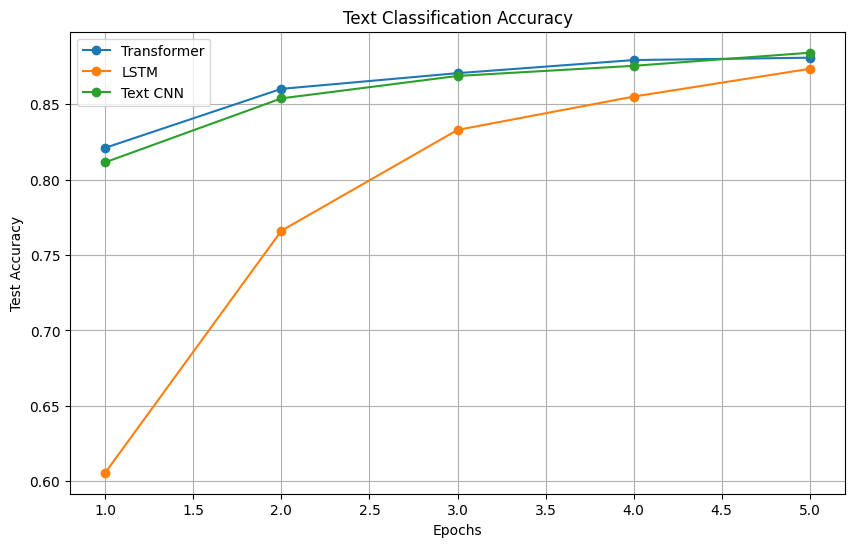


--- Final Comparison: Vision Classification ---


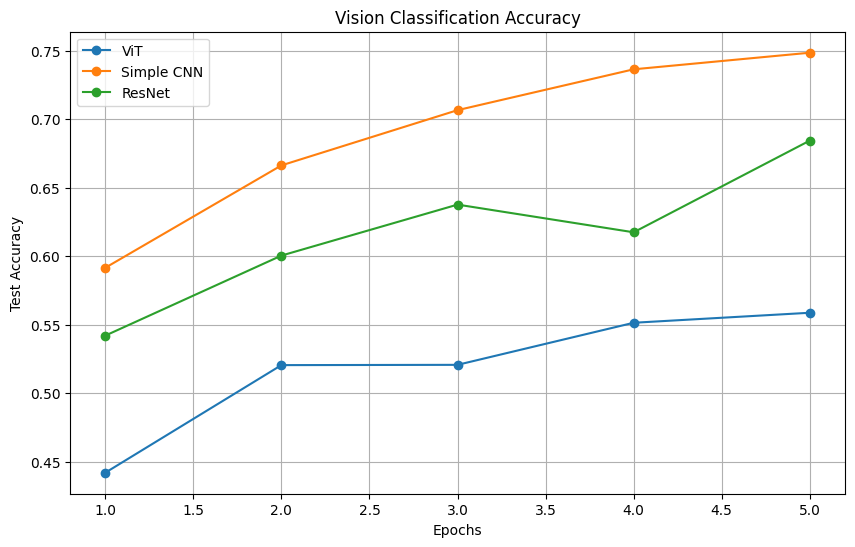

In [26]:
# Fix for the Plotting Error (Handling Tuple from train_and_evaluate)
import matplotlib.pyplot as plt

def plot_comparison_fixed(histories_with_time, labels, title):
    epochs_range = range(1, 6) # Sesuai setting 5 epoch
    plt.figure(figsize=(10, 6))

    for item, label in zip(histories_with_time, labels):
        # Mengekstrak history jika inputnya adalah tuple (history, time)
        if isinstance(item, tuple):
            h = item[0]
        else:
            h = item

        if h and 'test_acc' in h:
            plt.plot(range(1, len(h['test_acc']) + 1), h['test_acc'], marker='o', label=label)

    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Test Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# Pastikan variabel ini sudah ada di kernel (dari eksekusi sel sebelumnya)
try:
    print("--- Final Comparison: Text Classification ---")
    text_h = [history_tf, history_lstm, history_cnn_txt]
    text_l = ["Transformer", "LSTM", "Text CNN"]
    plot_comparison_fixed(text_h, text_l, "Text Classification Accuracy")

    print("\n--- Final Comparison: Vision Classification ---")
    # Gunakan history_resnet yang berhasil (jika ada)
    vision_h = [history_vit, history_cnn, history_resnet]
    vision_l = ["ViT", "Simple CNN", "ResNet"]
    plot_comparison_fixed(vision_h, vision_l, "Vision Classification Accuracy")
except NameError as e:
    print(f"Beberapa model belum selesai dilatih: {e}")

In [ ]:
# ==========================================
# 8. EKSPERIMEN WAJIB: VARIASI PATCH SIZE ViT
# ==========================================
print("Mulai Eksperimen ViT dengan Patch Size 8x8...")

# Mengubah patch_size menjadi 8 (sebelumnya 4)
model_vit_patch8 = SimpleViT(patch_size=8).to(device)
optimizer_vit_8 = optim.Adam(model_vit_patch8.parameters(), lr=0.001)

# Kita hitung parameternya untuk laporan
print(f"Jumlah parameter ViT (Patch 8x8): {count_parameters(model_vit_patch8):,}")

# Training ulang dengan patch yang lebih besar
history_vit_8, time_vit_8 = train_and_evaluate(
    model_vit_patch8, optimizer_vit_8, train_loader_vision, test_loader_vision,
    epochs=5, model_name="ViT Patch 8x8"
)

# Membandingkan Akurasi ViT Patch 4x4 vs Patch 8x8
plt.figure(figsize=(7, 5))
epochs = range(1, 6)
plt.plot(epochs, history_vit['test_acc'], 'b-', marker='o', label='ViT Patch 4x4')
plt.plot(epochs, history_vit_8['test_acc'], 'g-', marker='s', label='ViT Patch 8x8')
plt.title('Pengaruh Ukuran Patch pada Vision Transformer')
plt.xlabel('Epochs')
plt.ylabel('Test Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
# Update Plot untuk menyertakan Vision Triple Comparison
def plot_vision_triple(h1, l1, h2, l2, h3, l3):
    epochs = range(1, len(h1['test_acc']) + 1)
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, h1['test_acc'], 'b-o', label=l1)
    plt.plot(epochs, h2['test_acc'], 'r-s', label=l2)
    plt.plot(epochs, h3['test_acc'], 'g-^', label=l3)
    plt.title('Comparison: Vision Models Accuracy')
    plt.legend(); plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, h1['test_loss'], 'b-o', label=l1)
    plt.plot(epochs, h2['test_loss'], 'r-s', label=l2)
    plt.plot(epochs, h3['test_loss'], 'g-^', label=l3)
    plt.title('Comparison: Vision Models Loss')
    plt.legend(); plt.grid(True)
    plt.show()

try:
    plot_vision_triple(history_vit, "ViT", history_cnn, "Simple CNN", history_resnet, "ResNet")
except NameError as e:
    print(f"Error: {e}")

---
## IV. Implementasi GitHub Non-Klasifikasi
### A. Object Detection dengan Ultralytics YOLO
*   **Link Repository:** https://github.com/ultralytics/ultralytics
*   **Jenis Tugas:** Object Detection
*   **Model:** YOLOv8n (Nano)

In [ ]:
# ==========================================
# 1. SETUP REPOSITORY & DEPENDENCIES
# ==========================================
# Menginstal ultralytics (repository resmi YOLOv8)
!pip install ultralytics

import urllib.request
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ==========================================
# 2. DOWNLOAD GAMBAR SAMPEL & LOAD MODEL
# ==========================================
print("\nMengunduh gambar sampel dan memuat model YOLOv8 Nano...")
# Mengunduh gambar sampel jalanan yang ramai
image_url = "https://ultralytics.com/images/bus.jpg"
image_path = "bus.jpg"
urllib.request.urlretrieve(image_url, image_path)

# Memuat model YOLOv8 (Otomatis mengunduh bobot pre-trained yolov8n.pt)
model_yolo = YOLO('yolov8n.pt')

# ==========================================
# 3. INFERENSI SEBELUM MODIFIKASI (DEFAULT)
# ==========================================
print("Menjalankan inferensi bawaan (Default Conf = 0.25)...")
# Menjalankan deteksi dengan parameter bawaan
results_default = model_yolo(image_path)
res_img_default = results_default[0].plot() # Menghasilkan gambar dengan bounding box
res_img_default = cv2.cvtColor(res_img_default, cv2.COLOR_BGR2RGB) # Konversi warna untuk Matplotlib

# ==========================================
# 4. INFERENSI SETELAH MODIFIKASI KODE
# ==========================================
print("Menjalankan inferensi dengan modifikasi (Custom Conf = 0.85)...")
# MODIFIKASI: Kita mengintervensi parameter 'conf' (Confidence Threshold).
# Secara default, YOLO mendeteksi objek yang tingkat keyakinannya minimal 25% (0.25).
# Kita ubah menjadi 85% (0.85) agar model HANYA menampilkan objek yang ia yakini sangat akurat.
results_modified = model_yolo(image_path, conf=0.85)
res_img_modified = results_modified[0].plot()
res_img_modified = cv2.cvtColor(res_img_modified, cv2.COLOR_BGR2RGB)

# ==========================================
# 5. VISUALISASI KOMPARASI HASIL
# ==========================================
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(res_img_default)
plt.title(f"Sebelum Modifikasi (Default Conf=0.25)\nTotal Objek: {len(results_default[0].boxes)}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(res_img_modified)
plt.title(f"Setelah Modifikasi Kode (Conf=0.85)\nTotal Objek: {len(results_modified[0].boxes)}")
plt.axis('off')

plt.tight_layout()
plt.show()